# U-Net Skip Connection Ablation Study
## Football Semantic Segmentation (COCO format)

| Exp | Skip connections active |
|-----|-------------------------|
| 1   | Level 1 only (shallowest — 64ch, 256×256) |
| 2   | Level 2 only (middle — 128ch, 128×128) |
| 3   | Level 3 only (deepest — 256ch, 64×64) |
| 4   | All levels (standard U-Net) |

**Metrics:** IoU (Jaccard), Dice Coefficient

## 0. Install & Imports

In [91]:
!pip install -q pycocotools

In [92]:
import os, time, json, random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from sklearn.model_selection import train_test_split

from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 1. Dataset

In [93]:
ROOT     = Path('/kaggle/input/datasets/sadhliroomyprime/football-semantic-segmentation')
ANN_FILE = ROOT / 'COCO_Football Pixel.json'
IMG_DIR  = ROOT / 'images'

coco     = COCO(str(ANN_FILE))
cat_ids  = sorted(coco.getCatIds())
cat_map  = {cid: i + 1 for i, cid in enumerate(cat_ids)}  # 0 = background
NUM_CLASSES = len(cat_ids) + 1

print('NUM_CLASSES:', NUM_CLASSES)
print('Classes:', {c['name']: cat_map[c['id']] for c in coco.loadCats(cat_ids)})

img_ids = sorted(coco.getImgIds())
print('Total images:', len(img_ids))

loading annotations into memory...
Done (t=1.32s)
creating index...
index created!
NUM_CLASSES: 12
Classes: {'Team A': 1, 'Team B': 2, 'Goalkeeper A': 3, 'Goalkeeper B': 4, 'Audience': 5, 'Coaches & Officials': 6, 'Ball': 7, 'Ground': 8, 'Advertisements': 9, 'Referee': 10, 'Goal Bar': 11}
Total images: 100


In [94]:
IMG_H, IMG_W = 512, 512   # preserve detail from 1920x1080 source

def build_mask(coco_obj, img_info, cat_map):
    """Rasterise all polygon annotations for one image → (H, W) int64 mask."""
    h, w    = img_info['height'], img_info['width']
    mask    = np.zeros((h, w), dtype=np.int64)
    ann_ids = coco_obj.getAnnIds(imgIds=img_info['id'])
    anns    = coco_obj.loadAnns(ann_ids)
    for ann in anns:
        cls_idx = cat_map[ann['category_id']]
        rle     = coco_mask.frPyObjects(ann['segmentation'], h, w)
        rle     = coco_mask.merge(rle)
        m       = coco_mask.decode(rle).astype(bool)
        mask[m] = cls_idx
    return mask


class FootballSegDataset(Dataset):
    def __init__(self, coco_obj, img_ids, img_dir, cat_map, augment=False):
        self.coco    = coco_obj
        self.img_ids = img_ids
        self.img_dir = Path(img_dir)
        self.cat_map = cat_map
        self.augment = augment
        self.img_tf  = T.Compose([
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_info = self.coco.loadImgs(self.img_ids[idx])[0]
        img      = Image.open(self.img_dir / img_info['file_name']).convert('RGB')
        mask_arr = build_mask(self.coco, img_info, self.cat_map)

        img      = img.resize((IMG_W, IMG_H), Image.BILINEAR)
        mask_pil = Image.fromarray(mask_arr.astype(np.uint8)).resize(
                       (IMG_W, IMG_H), Image.NEAREST)

        # Augmentation (training only)
        if self.augment and random.random() > 0.5:
            img      = TF.hflip(img)
            mask_pil = TF.hflip(mask_pil)
        if self.augment and random.random() > 0.5:
            img      = TF.vflip(img)
            mask_pil = TF.vflip(mask_pil)
        if self.augment and random.random() > 0.5:
            angle    = random.uniform(-15, 15)
            img      = TF.rotate(img,      angle, interpolation=T.InterpolationMode.BILINEAR)
            mask_pil = TF.rotate(mask_pil, angle, interpolation=T.InterpolationMode.NEAREST)
        if self.augment and random.random() > 0.5:
            img = T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2)(img)

        img_t  = self.img_tf(img)
        mask_t = torch.from_numpy(np.array(mask_pil)).long().clamp(0, NUM_CLASSES - 1)
        return img_t, mask_t


# Split on 100 images: 80 train / 10 val / 10 test
train_ids, tmp_ids = train_test_split(img_ids, test_size=0.2,  random_state=SEED)
val_ids,  test_ids = train_test_split(tmp_ids,  test_size=0.5,  random_state=SEED)
print(f'Train: {len(train_ids)}  Val: {len(val_ids)}  Test: {len(test_ids)}')

BATCH    = 16   # 512x512 
train_ds = FootballSegDataset(coco, train_ids, IMG_DIR, cat_map, augment=True)
val_ds   = FootballSegDataset(coco, val_ids,   IMG_DIR, cat_map)
test_ds  = FootballSegDataset(coco, test_ids,  IMG_DIR, cat_map)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=4, pin_memory=True, persistent_workers=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

print(f'Batches — train: {len(train_dl)}  val: {len(val_dl)}  test: {len(test_dl)}')

Train: 80  Val: 10  Test: 10
Batches — train: 5  val: 1  test: 1


Image batch: torch.Size([16, 3, 512, 512]) | Mask batch: torch.Size([16, 512, 512])
Unique classes in batch: [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11]


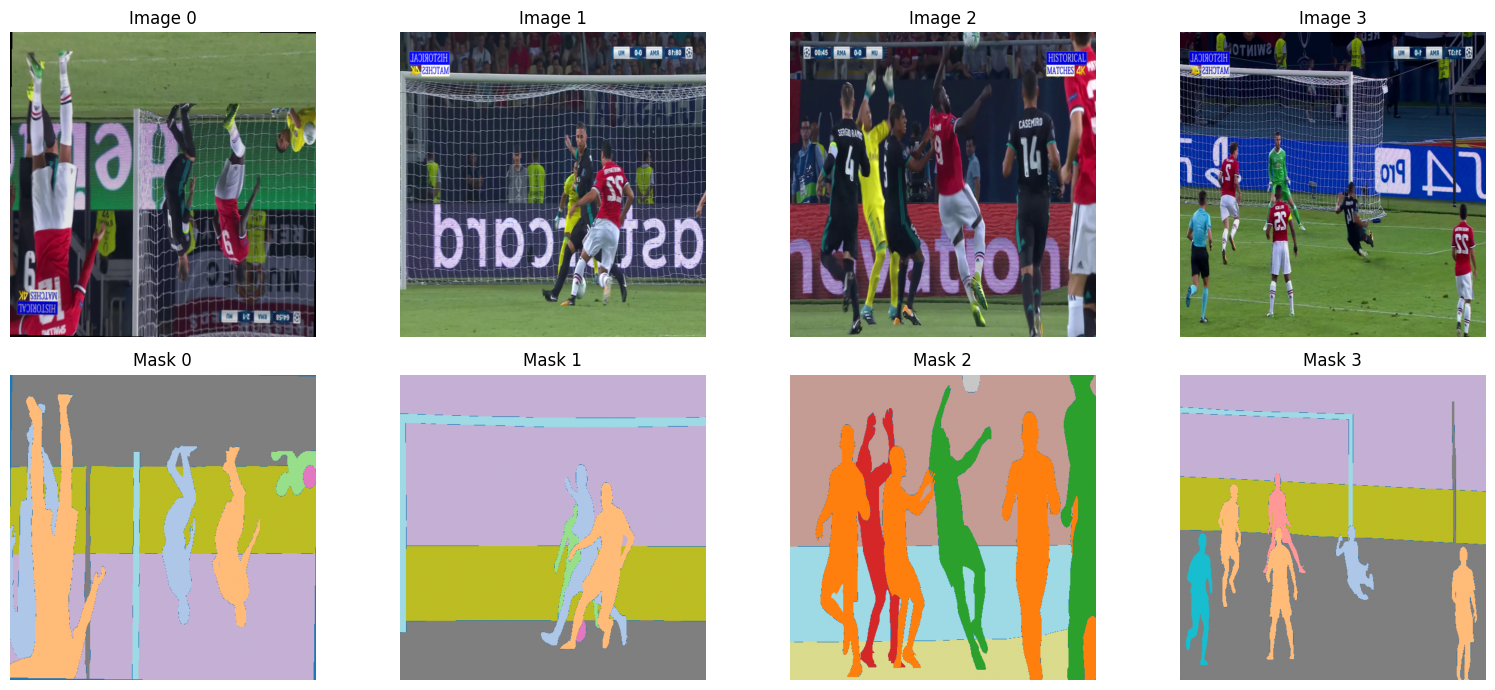

In [95]:
# Sanity visualisation
imgs, masks = next(iter(train_dl))
print('Image batch:', imgs.shape, '| Mask batch:', masks.shape)
print('Unique classes in batch:', masks.unique().tolist())

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i in range(4):
    img_show = (imgs[i] * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()
    axes[0, i].imshow(img_show);                           axes[0, i].set_title(f'Image {i}');  axes[0, i].axis('off')
    axes[1, i].imshow(masks[i].numpy(), cmap='tab20');     axes[1, i].set_title(f'Mask {i}');   axes[1, i].axis('off')
plt.tight_layout()
plt.show()

## 2. Model — U-Net with controllable skip connections

In [96]:
class DoubleConv(nn.Module):
    """(Conv → BN → ReLU) × 2"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class Down(nn.Module):
    """MaxPool2d → DoubleConv"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_ch, out_ch))
    def forward(self, x): return self.net(x)


class Up(nn.Module):
    """
    Decoder block.
    skip_active=True  → concatenate encoder feature map (standard U-Net)
    skip_active=False → upsample + conv only (no skip)
    """
    def __init__(self, in_ch, skip_ch, out_ch, skip_active=True):
        super().__init__()
        self.up          = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        cat_ch           = (in_ch // 2) + (skip_ch if skip_active else 0)
        self.conv        = DoubleConv(cat_ch, out_ch)
        self.skip_active = skip_active

    def forward(self, x, skip=None):
        x = self.up(x)
        if self.skip_active and skip is not None:
            dh = skip.size(2) - x.size(2)
            dw = skip.size(3) - x.size(3)
            x  = F.pad(x, [dw // 2, dw - dw // 2, dh // 2, dh - dh // 2])
            x  = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    """
    3-level U-Net.
    skip_mask = (L1, L2, L3)  —  True = skip active, False = skip removed.
    L1 = shallowest (64ch),  L3 = deepest (256ch, just above bottleneck).
    """
    def __init__(self, in_ch=3, num_classes=12,
                 features=(64, 128, 256),
                 skip_mask=(True, True, True)):
        super().__init__()
        f1, f2, f3 = features
        s1, s2, s3 = skip_mask

        # Encoder
        self.enc1       = DoubleConv(in_ch, f1)      # 512 → f1
        self.enc2       = Down(f1, f2)               # 256 → f2
        self.enc3       = Down(f2, f3)               # 128 → f3
        # Bottleneck
        self.bottleneck = Down(f3, f3 * 2)           #  64 → f3*2
        # Decoder
        self.dec3       = Up(f3 * 2, f3, f3, skip_active=s3)
        self.dec2       = Up(f3,     f2, f2, skip_active=s2)
        self.dec1       = Up(f2,     f1, f1, skip_active=s1)

        self.head       = nn.Conv2d(f1, num_classes, kernel_size=1)
        self.skip_mask  = skip_mask

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        b  = self.bottleneck(e3)

        d3 = self.dec3(b,  e3 if self.skip_mask[2] else None)
        d2 = self.dec2(d3, e2 if self.skip_mask[1] else None)
        d1 = self.dec1(d2, e1 if self.skip_mask[0] else None)

        return self.head(d1)


# Shape check
dummy = torch.randn(2, 3, 512, 512)
for sm in [(True,False,False),(False,True,False),(False,False,True),(True,True,True)]:
    out = UNet(num_classes=NUM_CLASSES, skip_mask=sm)(dummy)
    print(f'skip={sm} → {out.shape}')

skip=(True, False, False) → torch.Size([2, 12, 512, 512])
skip=(False, True, False) → torch.Size([2, 12, 512, 512])
skip=(False, False, True) → torch.Size([2, 12, 512, 512])
skip=(True, True, True) → torch.Size([2, 12, 512, 512])


In [97]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        # logits: [B, C, H, W]
        # targets: [B, H, W]

        probs = F.softmax(logits, dim=1)

        targets_one_hot = F.one_hot(
            targets,
            num_classes=logits.shape[1]
        ).permute(0, 3, 1, 2).float()

        intersection = (probs * targets_one_hot).sum(dim=(2,3))
        union = probs.sum(dim=(2,3)) + targets_one_hot.sum(dim=(2,3))

        dice = (2 * intersection + self.smooth) / (union + self.smooth)

        # Ignore background class (class 0)
        dice = dice[:, 1:]
        
        return 1 - dice.mean()

## 3. Metrics

In [98]:
def compute_confusion(preds, targets, num_classes):
    if preds.ndim == 4:
        preds = preds.argmax(dim=1)
    tp = torch.zeros(num_classes, device=preds.device)
    fp = torch.zeros(num_classes, device=preds.device)
    fn = torch.zeros(num_classes, device=preds.device)
    for c in range(num_classes):
        tp[c] = ((preds == c) & (targets == c)).sum()
        fp[c] = ((preds == c) & (targets != c)).sum()
        fn[c] = ((preds != c) & (targets == c)).sum()
    return tp, fp, fn


def iou_dice_from_confusion(tp, fp, fn, smooth=1e-6):
    # Slice out index 0 to ignore the background class entirely
    tp = tp[1:]
    fp = fp[1:]
    fn = fn[1:]
    
    present = (tp + fp + fn) > 0  # Ignore classes never seen in target or prediction
    iou  = (tp + smooth) / (tp + fp + fn + smooth)
    dice = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
    return iou[present].mean().item(), dice[present].mean().item()

## 4. Training loop

In [99]:
def train_one_epoch(model, loader, optimizer, criterion, device, num_classes):
    model.train()
    total_loss = 0
    tp = fp = fn = torch.zeros(num_classes, device=device)
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            total_loss += loss.item()
            btp, bfp, bfn = compute_confusion(logits, masks, num_classes)
            tp, fp, fn = tp + btp, fp + bfp, fn + bfn
    iou, dice = iou_dice_from_confusion(tp, fp, fn)
    return total_loss / len(loader), iou, dice


@torch.no_grad()
def evaluate(model, loader, criterion, device, num_classes):
    model.eval()
    total_loss = 0
    tp = fp = fn = torch.zeros(num_classes, device=device)
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        total_loss += criterion(logits, masks).item()
        btp, bfp, bfn = compute_confusion(logits, masks, num_classes)
        tp, fp, fn = tp + btp, fp + bfp, fn + bfn
    iou, dice = iou_dice_from_confusion(tp, fp, fn)
    return total_loss / len(loader), iou, dice


def run_experiment(exp_name, skip_mask, epochs=100, lr=1e-3, save_dir='checkpoints'):
    os.makedirs(save_dir, exist_ok=True)
    ckpt = f'{save_dir}/{exp_name}.pth'

    model     = UNet(num_classes=NUM_CLASSES, skip_mask=skip_mask).to(DEVICE)
    if torch.cuda.device_count() > 1:
        print(f'Using {torch.cuda.device_count()} GPUs')
        model = nn.DataParallel(model)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    ce_loss = nn.CrossEntropyLoss()
    dice_loss = DiceLoss()

    def criterion(outputs, targets):
        return ce_loss(outputs, targets) + dice_loss(outputs, targets)

    history      = defaultdict(list)
    best_val_iou = 0.0

    print(f'\n{"═" * 62}')
    print(f'  {exp_name}   skip=L1:{skip_mask[0]} L2:{skip_mask[1]} L3:{skip_mask[2]}')
    print(f'{"═" * 62}')

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_iou, tr_dice = train_one_epoch(model, train_dl, optimizer, criterion, DEVICE, NUM_CLASSES)
        vl_loss, vl_iou, vl_dice = evaluate(model, val_dl, criterion, DEVICE, NUM_CLASSES)
        scheduler.step()

        for k, v in [('tr_loss', tr_loss), ('tr_iou', tr_iou), ('tr_dice', tr_dice),
                     ('vl_loss', vl_loss), ('vl_iou', vl_iou), ('vl_dice', vl_dice)]:
            history[k].append(v)

        if vl_iou > best_val_iou:
            best_val_iou = vl_iou
            state = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
            torch.save(state, ckpt)

        if epoch % 5 == 0 or epoch == 1:
            print(f'Ep {epoch:3d}/{epochs} | '
                  f'Loss {tr_loss:.4f}/{vl_loss:.4f} | '
                  f'IoU {tr_iou:.4f}/{vl_iou:.4f} | '
                  f'Dice {tr_dice:.4f}/{vl_dice:.4f} | '
                  f'{time.time() - t0:.1f}s')

    state = torch.load(ckpt, map_location=DEVICE)
    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(state)
    else:
        model.load_state_dict(state)
    ts_loss, ts_iou, ts_dice = evaluate(model, test_dl, criterion, DEVICE, NUM_CLASSES)
    print(f'\n  ✔ TEST  IoU={ts_iou:.4f}  Dice={ts_dice:.4f}  Loss={ts_loss:.4f}')

    return model, history, {'test_iou': ts_iou, 'test_dice': ts_dice, 'test_loss': ts_loss}

## 5. Run all four experiments

In [100]:
EXPERIMENTS = {
    'Exp1_L1_only'  : (True,  False, False),
    'Exp2_L2_only'  : (False, True,  False),
    'Exp3_L3_only'  : (False, False, True ),
    'Exp4_All_skips': (True,  True,  True ),
}

EPOCHS = 100

all_histories    = {}
all_test_results = {}
all_models       = {}

for name, skip_mask in EXPERIMENTS.items():
    model, hist, test_res = run_experiment(name, skip_mask, epochs=EPOCHS)
    all_histories[name]    = hist
    all_test_results[name] = test_res
    all_models[name]       = model

print('\nAll experiments complete.')

Using 2 GPUs

══════════════════════════════════════════════════════════════
  Exp1_L1_only   skip=L1:True L2:False L3:False
══════════════════════════════════════════════════════════════
Ep   1/100 | Loss 2.7877/3.2979 | IoU 0.1353/0.1286 | Dice 0.1916/0.1503 | 12.7s
Ep   5/100 | Loss 1.7370/1.8466 | IoU 0.2518/0.2490 | Dice 0.3122/0.3062 | 11.8s
Ep  10/100 | Loss 1.4775/1.5221 | IoU 0.3295/0.3186 | Dice 0.4059/0.3890 | 11.9s
Ep  15/100 | Loss 1.3051/1.4342 | IoU 0.3954/0.3784 | Dice 0.4895/0.4685 | 11.8s
Ep  20/100 | Loss 1.2013/1.2378 | IoU 0.4302/0.4358 | Dice 0.5207/0.5243 | 11.7s
Ep  25/100 | Loss 1.0985/1.1520 | IoU 0.4508/0.4667 | Dice 0.5379/0.5519 | 11.9s
Ep  30/100 | Loss 1.0627/1.0970 | IoU 0.4749/0.4857 | Dice 0.5668/0.5680 | 11.9s
Ep  35/100 | Loss 0.9787/0.9795 | IoU 0.5257/0.5500 | Dice 0.6313/0.6459 | 11.7s
Ep  40/100 | Loss 0.9836/0.9122 | IoU 0.5541/0.5739 | Dice 0.6672/0.6715 | 11.8s
Ep  45/100 | Loss 0.9774/0.9764 | IoU 0.5580/0.5682 | Dice 0.6721/0.6761 | 11.9s
Ep

## 6. Results table

In [101]:
rows = []
for name, mask in EXPERIMENTS.items():
    res = all_test_results[name]
    rows.append({
        'Experiment': name,
        'L1 Skip'  : '✔' if mask[0] else '✘',
        'L2 Skip'  : '✔' if mask[1] else '✘',
        'L3 Skip'  : '✔' if mask[2] else '✘',
        'Test IoU' : round(res['test_iou'],  4),
        'Test Dice': round(res['test_dice'], 4),
        'Test Loss': round(res['test_loss'], 4),
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
best = df.loc[df['Test IoU'].idxmax()]
print(f"\nBest: {best['Experiment']}  IoU={best['Test IoU']}  Dice={best['Test Dice']}")

    Experiment L1 Skip L2 Skip L3 Skip  Test IoU  Test Dice  Test Loss
  Exp1_L1_only       ✔       ✘       ✘    0.6410     0.7367     0.8059
  Exp2_L2_only       ✘       ✔       ✘    0.6686     0.7556     0.7712
  Exp3_L3_only       ✘       ✘       ✔    0.5244     0.5919     0.8925
Exp4_All_skips       ✔       ✔       ✔    0.7101     0.7870     0.7364

Best: Exp4_All_skips  IoU=0.7101  Dice=0.787


## 7. Training curves

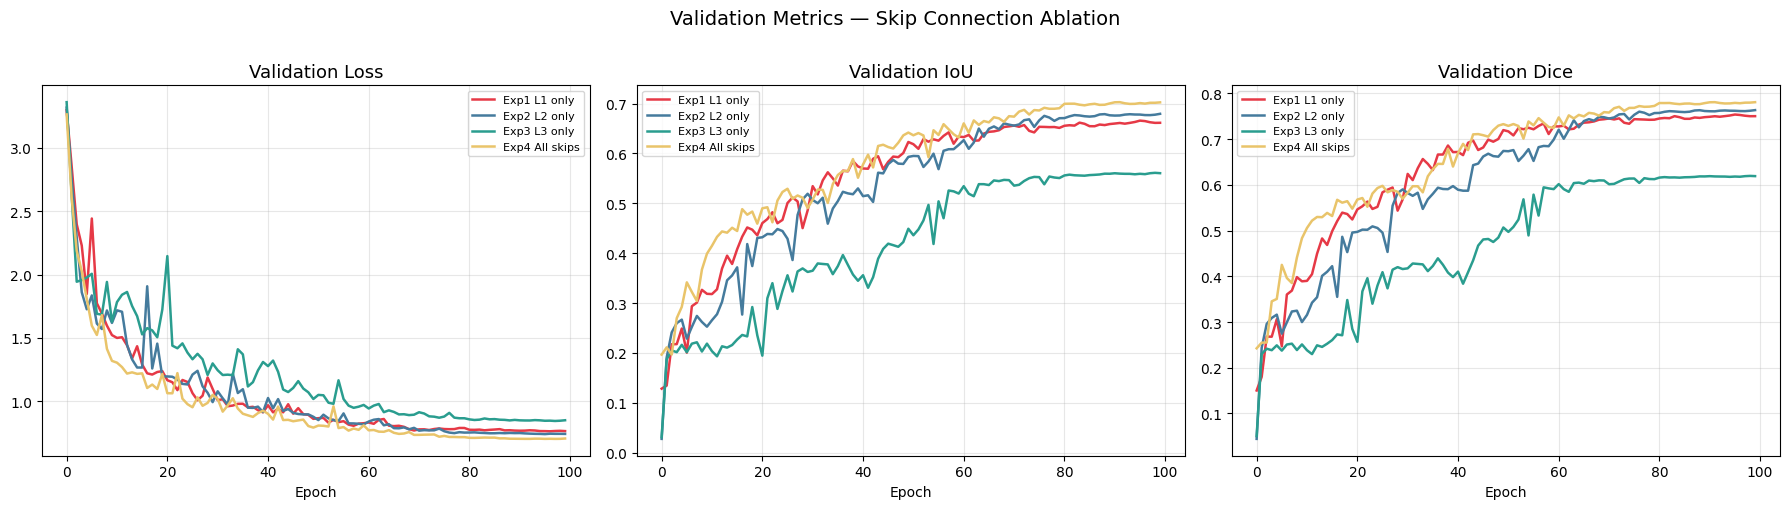

In [102]:
colors  = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A']
metrics = [('vl_loss', 'Validation Loss'), ('vl_iou', 'Validation IoU'), ('vl_dice', 'Validation Dice')]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (key, title) in zip(axes, metrics):
    for (name, hist), colour in zip(all_histories.items(), colors):
        ax.plot(hist[key], label=name.replace('_', ' '), color=colour, linewidth=1.8)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Validation Metrics — Skip Connection Ablation', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

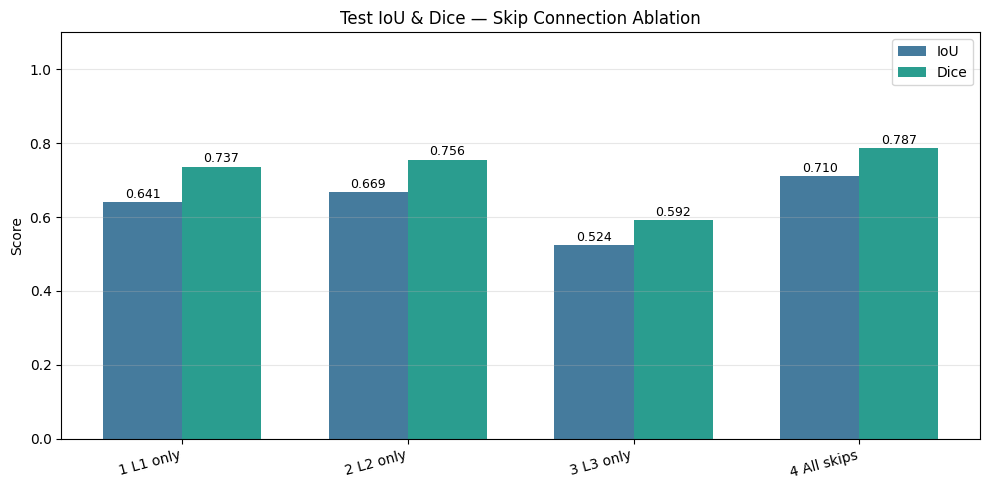

In [103]:
# Bar chart
exp_labels = [n.replace('Exp', '').replace('_', ' ') for n in df['Experiment']]
x, w = np.arange(len(exp_labels)), 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w / 2, df['Test IoU'],  w, label='IoU',  color='#457B9D')
bars2 = ax.bar(x + w / 2, df['Test Dice'], w, label='Dice', color='#2A9D8F')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(exp_labels, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Test IoU & Dice — Skip Connection Ablation')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Qualitative predictions

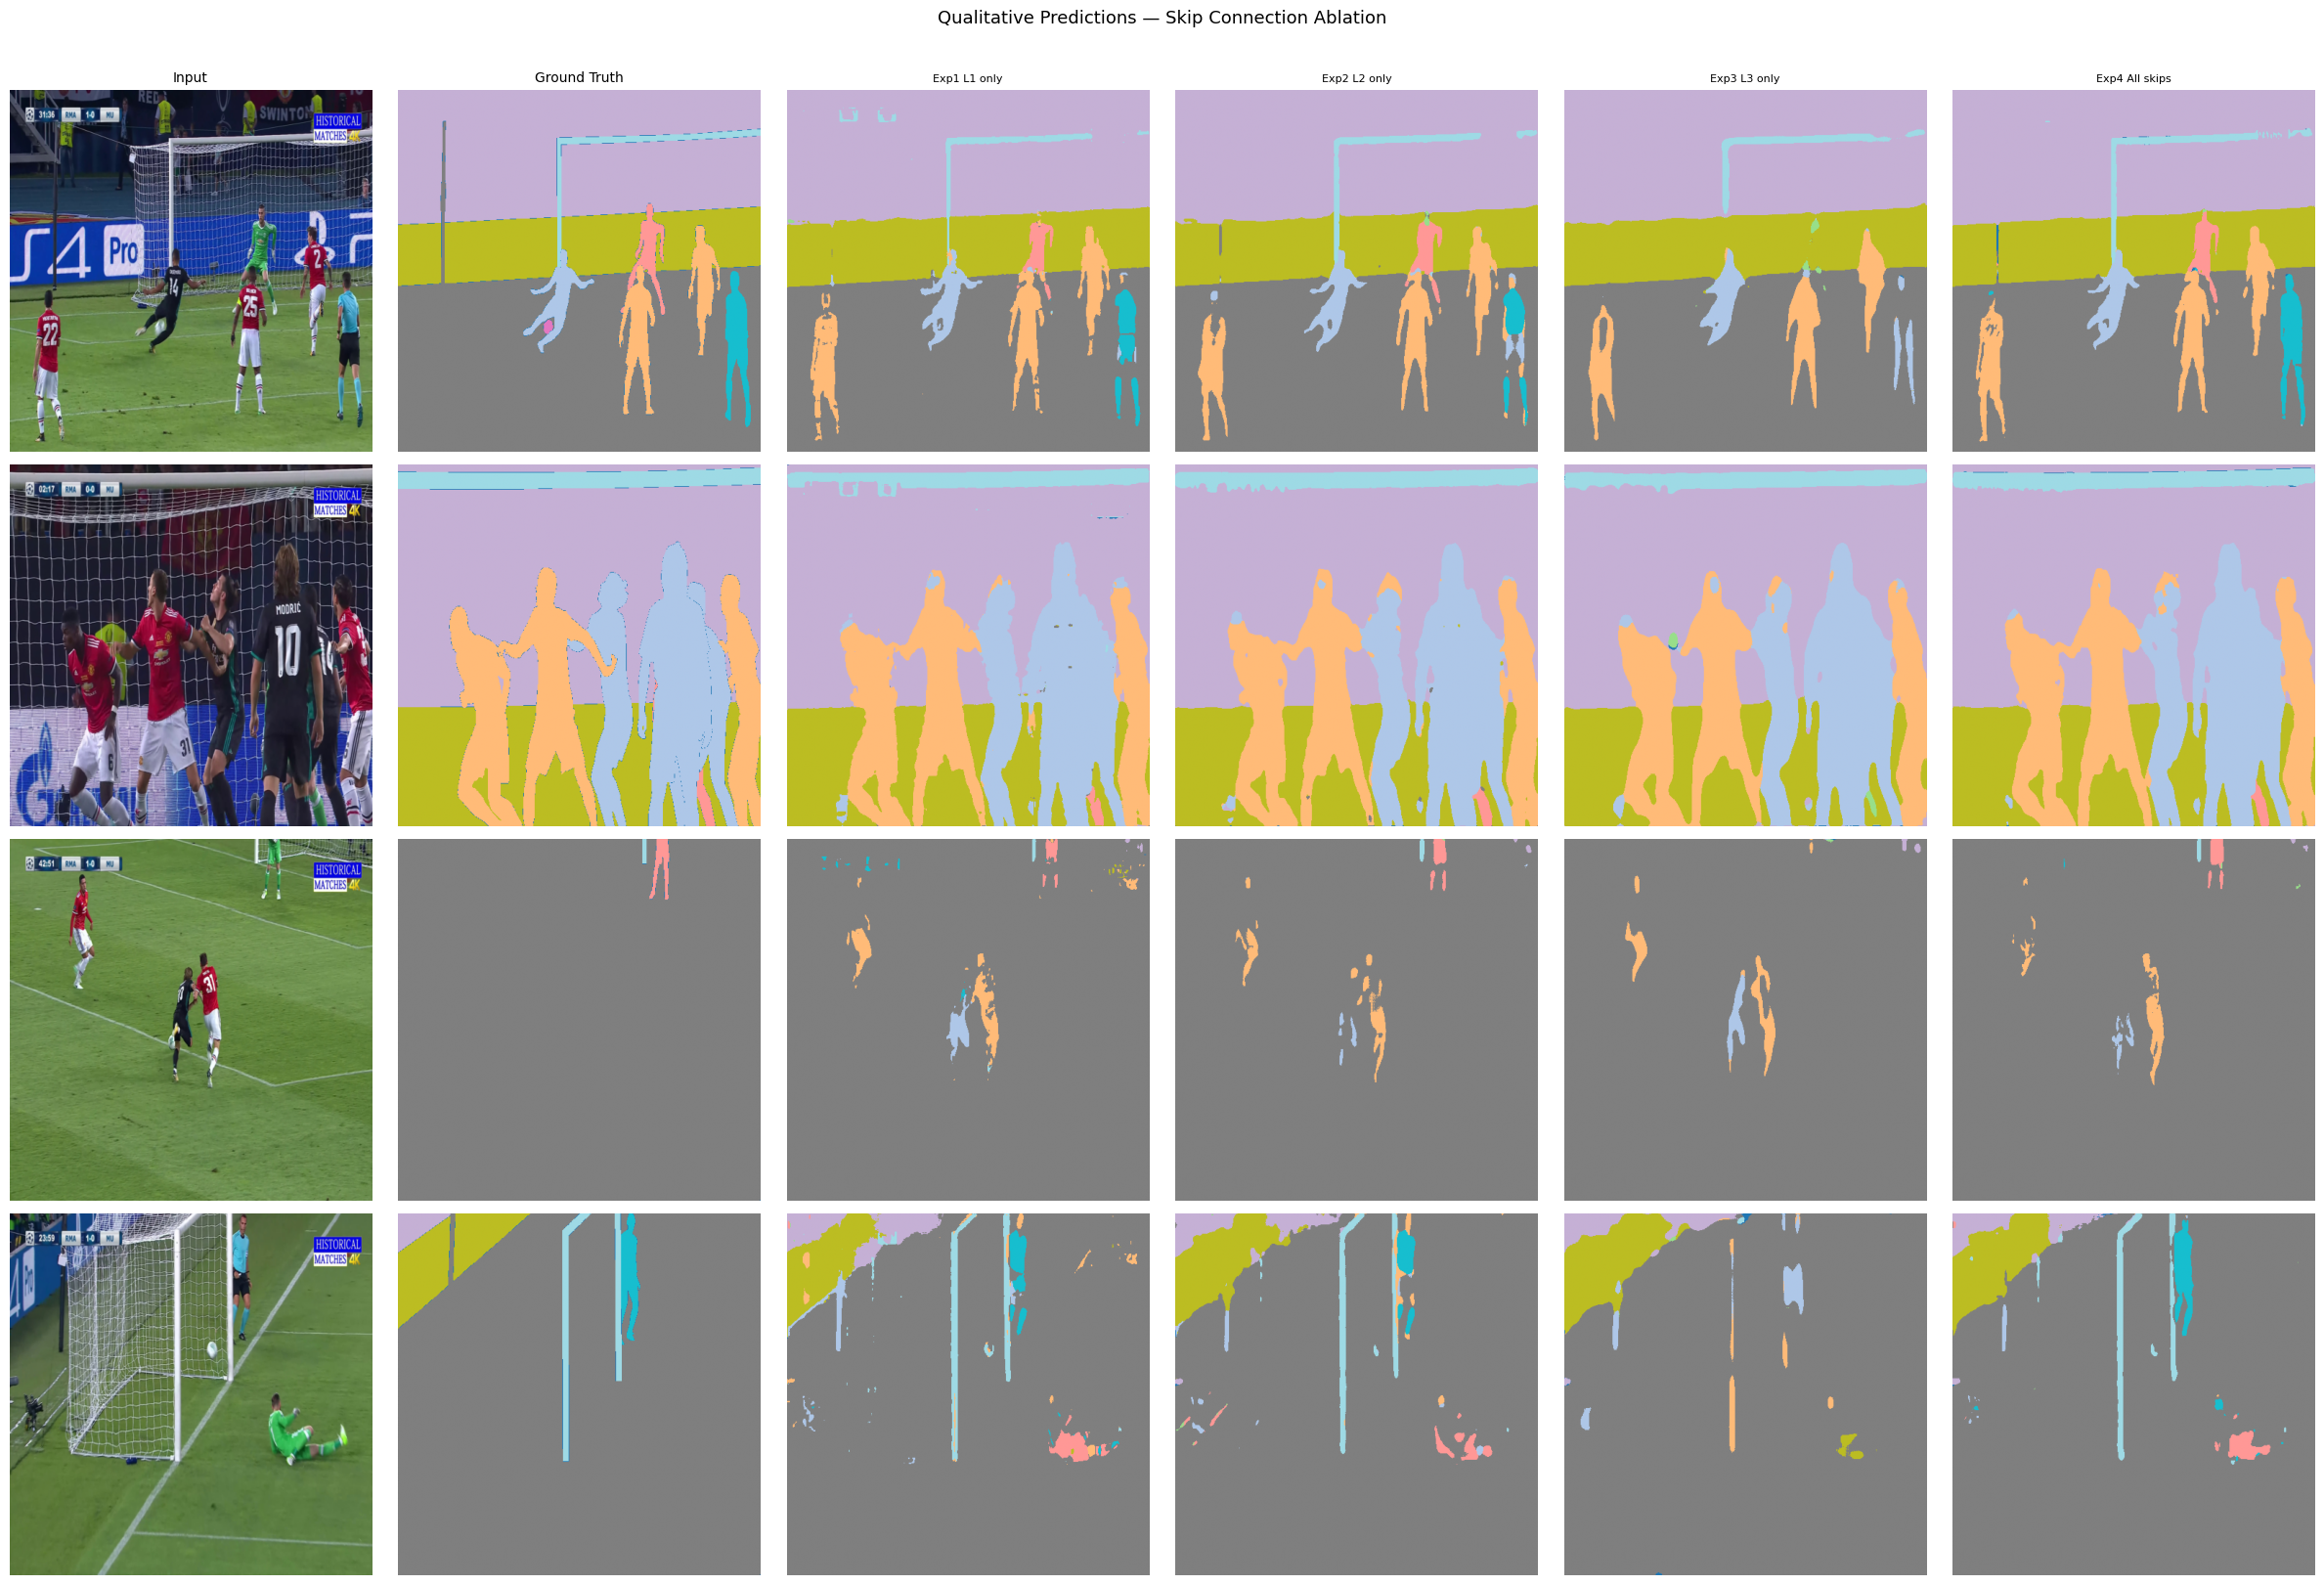

In [104]:
@torch.no_grad()
def get_preds(model, loader, n=4):
    model.eval()
    imgs, masks = next(iter(loader))
    imgs_d = imgs[:n].to(DEVICE)
    preds  = model(imgs_d).argmax(dim=1).cpu()
    return imgs[:n], masks[:n], preds


mean      = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std       = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
n_show    = 4
exp_names = list(EXPERIMENTS.keys())

# Grab the same images for all experiments using a fixed loader state
ref_imgs, ref_masks, _ = get_preds(all_models[exp_names[0]], test_dl, n=n_show)

# Re-get predictions for every model on the same batch
all_preds = {}
for name, model in all_models.items():
    _, _, pred      = get_preds(model, test_dl, n=n_show)
    all_preds[name] = pred

n_cols = len(exp_names) + 2   # input + GT + 4 experiments
fig, axes = plt.subplots(n_show, n_cols, figsize=(4 * n_cols, 4 * n_show))

for row in range(n_show):
    img_show = (ref_imgs[row] * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()
    axes[row, 0].imshow(img_show)
    axes[row, 0].set_title('Input'      if row == 0 else '', fontsize=10)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(ref_masks[row].numpy(), cmap='tab20', vmin=0, vmax=NUM_CLASSES - 1)
    axes[row, 1].set_title('Ground Truth' if row == 0 else '', fontsize=10)
    axes[row, 1].axis('off')

    for col, name in enumerate(exp_names):
        axes[row, col + 2].imshow(all_preds[name][row].numpy(), cmap='tab20',
                                  vmin=0, vmax=NUM_CLASSES - 1)
        axes[row, col + 2].set_title(name.replace('_', ' ') if row == 0 else '', fontsize=8)
        axes[row, col + 2].axis('off')

plt.suptitle('Qualitative Predictions — Skip Connection Ablation', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('predictions.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Comprehensive Conclusion

---

### Summary Results Table

| Experiment | L1 Skip | L2 Skip | L3 Skip | Test IoU | Test Dice |
|------------|:-------:|:-------:|:-------:|:--------:|:---------:|
| Exp 1 — L1 only   | ✔ | ✘ | ✘ | 0.6410 | 0.7367 |
| Exp 2 — L2 only   | ✘ | ✔ | ✘ | 0.6686 | 0.7556 |
| Exp 3 — L3 only   | ✘ | ✘ | ✔ | 0.5244 | 0.5919 |
| **Exp 4 — All skips** | ✔ | ✔ | ✔ | **0.7101** | **0.7870** |

---

The results agree with standard U-Net theory. The full model with all three skip connections (Exp 4) got the best score (IoU = 0.7101, Dice = 0.7870). It also trained smoothly, with train and validation scores staying close, so it did not overfit.

Among the single-skip models, the level mattered. Exp 2 (Level-2 only) beat Exp 1 (Level-1 only), and both beat Exp 3 (Level-3 only). This suggests the mid-level skip keeps the most useful spatial detail. The deepest skip alone keeps the least, probably because most fine detail is already lost by that depth.

**Exp 4 is the best choice for this dataset.** Combining all three skip levels gives the decoder both fine detail and strong semantic context.

One limit: the test set is small (10 images) and each experiment ran only once. Repeating with more seeds and a bigger test set would make the ranking more reliable.

In [105]:
df.to_csv('ablation_results.csv', index=False)
print('Saved ablation_results.csv')
print(df.to_string(index=False))

Saved ablation_results.csv
    Experiment L1 Skip L2 Skip L3 Skip  Test IoU  Test Dice  Test Loss
  Exp1_L1_only       ✔       ✘       ✘    0.6410     0.7367     0.8059
  Exp2_L2_only       ✘       ✔       ✘    0.6686     0.7556     0.7712
  Exp3_L3_only       ✘       ✘       ✔    0.5244     0.5919     0.8925
Exp4_All_skips       ✔       ✔       ✔    0.7101     0.7870     0.7364
